# Chicago Boundaries Analysis: Community Areas & Zoning Districts

## Context
Following the exploration of the Brás neighborhood in São Paulo, this notebook expands our view to the entire city of Chicago. We will analyze the broader geospatial boundaries, focusing on **Community Areas** and **Zoning Districts**. 

## Objectives
1. **Load and inspect** the Chicago Community Areas and Zoning Districts boundaries.
2. **Visualize** the community areas to get a macro-level understanding of Chicago's regions.
3. **Analyze** the zoning districts to understand land use patterns across the city.
4. **Compare** this broader context to our specific needs for finding a match for the Brás district in São Paulo.


In [21]:
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as cx

# Set plotting defaults
plt.rcParams['figure.figsize'] = (14, 10)
plt.style.use('ggplot')

# Base path for our data
DATA_DIR = '../analysis/data'


## 1. Data Loading

We will load two primary datasets from our data directory:
1. **Community Areas**: The 77 officially defined community areas in Chicago.
2. **Zoning Districts**: The current zoning boundaries defining land use.


In [22]:
# Load Community Areas
print("Loading Community Areas...")
community_areas_gdf = gpd.read_file(os.path.join(DATA_DIR, 'Boundaries_-_Community_Areas_20260831.geojson'))
print(f"Loaded {len(community_areas_gdf)} Community Areas.")

# Load Zoning Districts
print("Loading Zoning Districts (This might take a moment as the file is large)...")
zoning_gdf = gpd.read_file(os.path.join(DATA_DIR, 'Boundaries_-_Zoning_Districts_(current)_20260831.geojson'))
print(f"Loaded {len(zoning_gdf)} Zoning Districts.")


Loading Community Areas...
Loaded 77 Community Areas.
Loading Zoning Districts (This might take a moment as the file is large)...
Loaded 14929 Zoning Districts.


## 2. Community Areas Analysis

Chicago is divided into 77 community areas. Understanding these regions is crucial for selecting a neighborhood comparable to Brás. Let's visualize them.


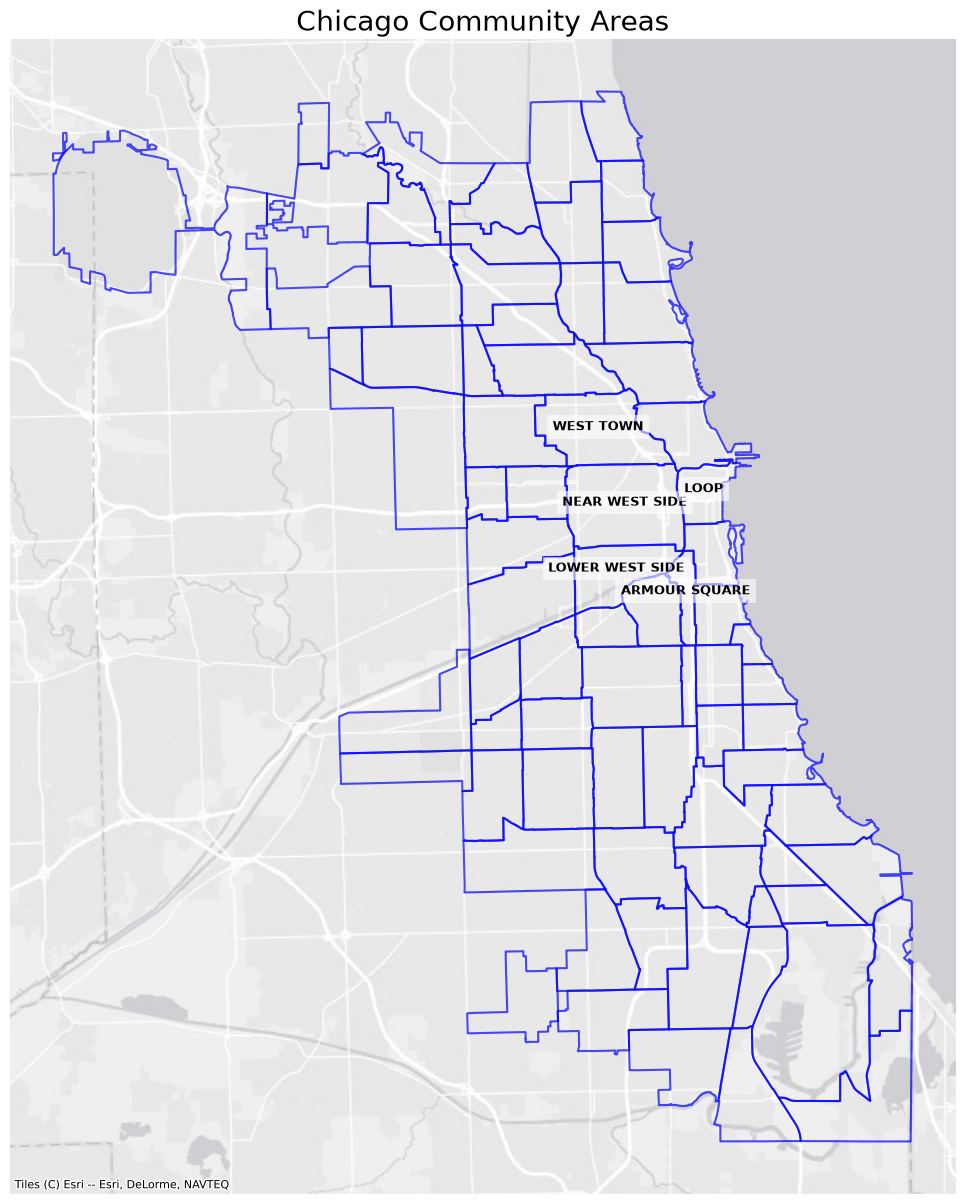

In [23]:
# Reproject to Web Mercator (EPSG:3857) for Contextily basemap compatibility
community_areas_web = community_areas_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(15, 15))

# Plot Community Areas
community_areas_web.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=1.5, alpha=0.7)

# Add labels for a few key community areas to orient ourselves
for idx, row in community_areas_web.iterrows():
    # Only label some to avoid clutter, e.g., Near West Side, Lower West Side (Pilsen), Loop
    if row['community'] in ['NEAR WEST SIDE', 'LOWER WEST SIDE', 'LOOP', 'WEST TOWN', 'ARMOUR SQUARE']:
        plt.annotate(text=row['community'], 
                     xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                     horizontalalignment='center', 
                     fontsize=9, 
                     fontweight='bold',
                     bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# Add Basemap using OpenStreetMap directly
cx.add_basemap(ax, source=cx.providers.Esri.WorldGrayCanvas)

ax.set_axis_off()
ax.set_title("Chicago Community Areas", fontsize=20)
plt.show()


## 3. Zoning Districts Analysis

Zoning determines how land can be used (residential, commercial, manufacturing, etc.). Brás is characterized by intense commercial and industrial activity mixed with residential. Let's look at Chicago's zoning distribution.


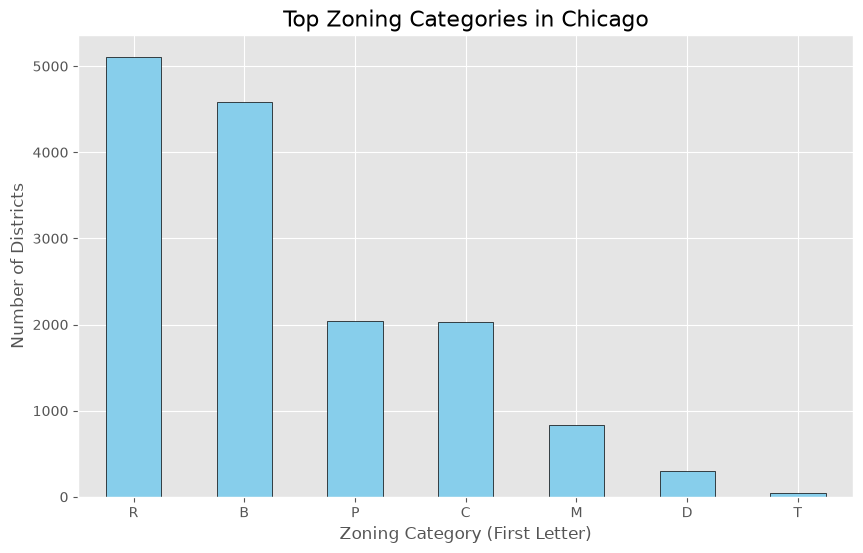

In [24]:
# Extract the primary zoning category (e.g., 'B' for Business, 'C' for Commercial, 'M' for Manufacturing, 'R' for Residential)
# The 'zone_class' column typically holds this info
zoning_gdf['zoning_category'] = zoning_gdf['zone_class'].str[0]

# Count the distribution of major zoning categories
zoning_counts = zoning_gdf['zoning_category'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
zoning_counts.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
ax.set_title("Top Zoning Categories in Chicago", fontsize=16)
ax.set_xlabel("Zoning Category (First Letter)")
ax.set_ylabel("Number of Districts")
plt.xticks(rotation=0)
plt.show()


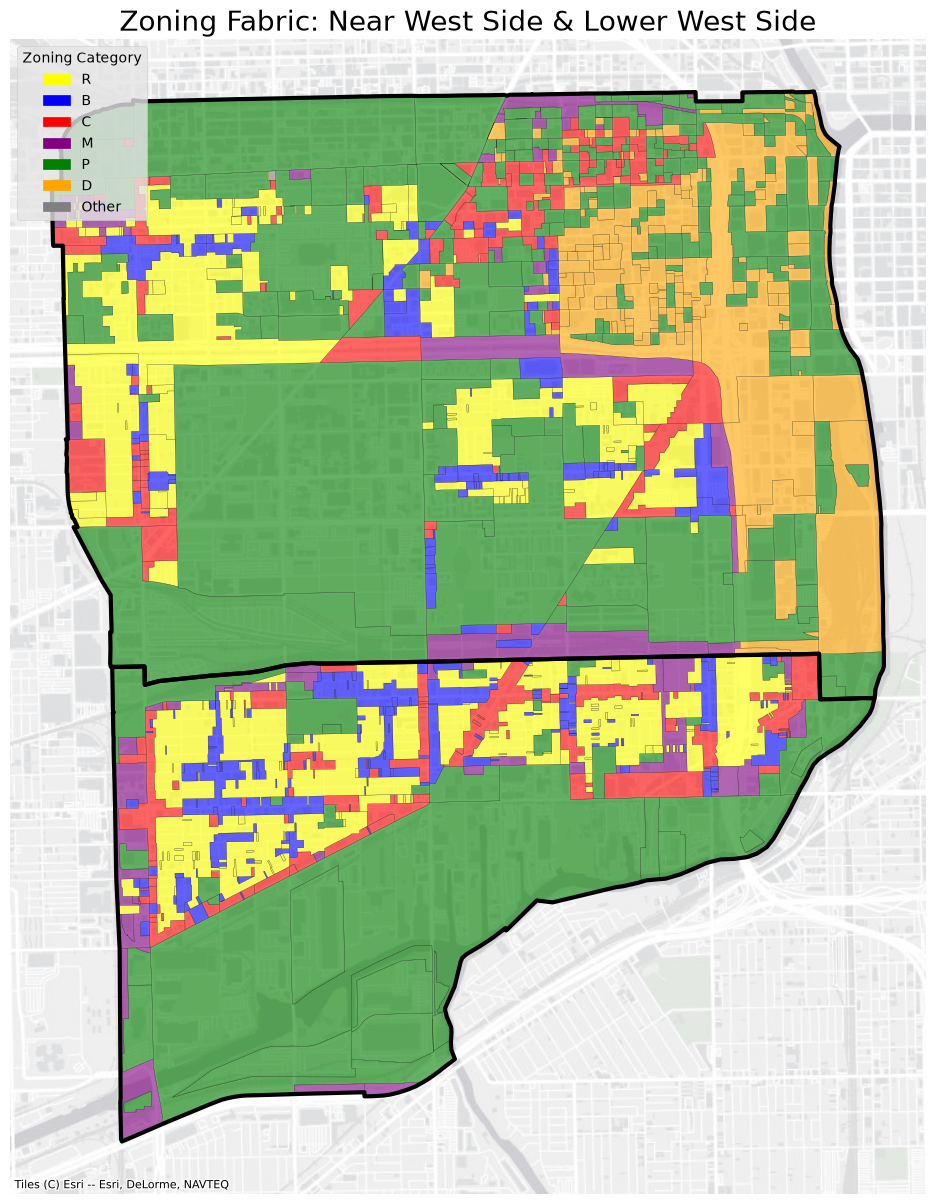

In [25]:
# Let's map a specific region to see the zoning fabric in detail.
# We'll focus on the Near West Side and Lower West Side (Pilsen) area.

# Get the geometry of Near West Side and Lower West Side
target_communities = community_areas_gdf[community_areas_gdf['community'].isin(['NEAR WEST SIDE', 'LOWER WEST SIDE'])]
target_bounds = target_communities.total_bounds

# Filter zoning districts that intersect with our target bounding box
zoning_subset = gpd.clip(zoning_gdf, target_communities)

# Reproject to Web Mercator
zoning_subset_web = zoning_subset.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(15, 15))

# Create a color map for major categories
color_dict = {'R': 'yellow', 'B': 'blue', 'C': 'red', 'M': 'purple', 'P': 'green', 'D': 'orange'}
zoning_subset_web['color'] = zoning_subset_web['zoning_category'].map(color_dict).fillna('gray')

# Plot
zoning_subset_web.plot(ax=ax, color=zoning_subset_web['color'], edgecolor='black', linewidth=0.2, alpha=0.6)

# Overlay community area boundaries
target_communities.to_crs(epsg=3857).plot(ax=ax, facecolor='none', edgecolor='black', linewidth=3)

# Add Basemap (with OpenStreetMap fallback) to avoid API key requirement
cx.add_basemap(ax, source=cx.providers.Esri.WorldGrayCanvas)

ax.set_axis_off()
ax.set_title("Zoning Fabric: Near West Side & Lower West Side", fontsize=20)

# Custom legend
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=color, label=label) for label, color in color_dict.items()]
legend_handles.append(mpatches.Patch(color='gray', label='Other'))
ax.legend(handles=legend_handles, title="Zoning Category", loc='upper left')

plt.show()


## 4. Synthesis: Finding the Brás Equivalent

Brás, SP, is characterized by:
1. **Intense Commercial/Retail Activity** (Garment district).
2. **Dense Blocks** with a mix of residential and industrial history.
3. **High Pedestrian Traffic**.

From our analysis above, the **Manufacturing (M)** and **Commercial (C)** zones interwoven with **Residential (R)** zones in areas like the **Near West Side** (Fulton Market/West Loop) and **Lower West Side** (Pilsen) exhibit a remarkably similar zoning fabric to Brás. The transition of former industrial spaces into dense commercial and mixed-use areas mirrors the urban evolution seen in central São Paulo.

### Next Steps
* Proceed with detailed network analysis (OSMnx) on these specific target communities.
* Extract sidewalk networks and compare structural metrics (node degree, centrality) against the Brás baseline.
